# TAO ADCP Velocity: Inter-Mooring Statistics
0°N equatorial moorings: 170°W, 140°W, 110°W — daily ADCP, 2012–2016

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [2]:
DATA_DIR = Path('/data/SO3/edavenport/TAO_2012to2016_daily')
FIG_DIR  = Path('2012to2016/depth_space_figures')

for subdir in ['overview', 'profiles', 'correlations', 'cross_correlation']:
    (FIG_DIR / subdir).mkdir(parents=True, exist_ok=True)

# ordered west to east
MOORING_FILES = {
    '170°W': 'ADCP_2012to2016_0N170W_daily.cdf',
    '140°W': 'ADCP_2012to2016_0N140W_daily.cdf',
    '110°W': 'ADCP_2012to2016_0N110W_daily.cdf',
}
MOORINGS = list(MOORING_FILES.keys())

# all unique ordered pairs (west to east)
PAIRS = [('170°W', '140°W'), ('170°W', '110°W'), ('140°W', '110°W')]
PAIR_LABELS = ['170°W – 140°W', '170°W – 110°W', '140°W – 110°W']

MOORING_COLORS = dict(zip(MOORINGS, sns.color_palette('colorblind', 3)))
PAIR_COLORS    = sns.color_palette('Set2', 3)
PAIR_LS = ['-', '-', '-']

sns.set_style('ticks')
sns.set_context('notebook', font_scale=1.05)

SAVE_KW = dict(dpi=150, bbox_inches='tight')

## Load Data

In [3]:
datasets = {}
for label, fname in MOORING_FILES.items():
    # squeeze out singleton lat/lon dimensions
    datasets[label] = xr.open_dataset(DATA_DIR / fname).squeeze(['lat', 'lon'])

# u (eastward) and v (northward); NaN already set where quality flag == 0
# original units are cm/s; convert to m/s
u = {k: ds['u_1205'] * 0.01 for k, ds in datasets.items()}
v = {k: ds['v_1206'] * 0.01 for k, ds in datasets.items()}

for label, ds in datasets.items():
    t0 = np.datetime_as_string(ds.time.values[0],  unit='D')
    t1 = np.datetime_as_string(ds.time.values[-1], unit='D')
    print(f"{label:6s}: {t0} – {t1}  "
          f"depth {ds.depth.values[0]:.0f}–{ds.depth.values[-1]:.0f} m  "
          f"({len(ds.depth)} levels)  "
          f"u NaN: {np.isnan(u[label].values).mean():.1%}")

170°W : 2012-01-01 – 2016-12-31  depth 10–315 m  (62 levels)  u NaN: 26.5%
140°W : 2012-01-01 – 2016-04-04  depth 10–295 m  (58 levels)  u NaN: 28.1%
110°W : 2012-01-01 – 2016-12-31  depth 10–315 m  (62 levels)  u NaN: 29.6%


## ONI Index
Monthly ONI values interpolated to daily resolution for use as scatter / hodograph color.

In [4]:
# Monthly ONI: center-month mapping (DJF→Jan, JFM→Feb, ..., NDJ→Dec) for year listed
# 2011 included to anchor interpolation at the start of the 2012 record
ONI_MONTHLY_RAW = {
    2011: [-1.3, -1.0, -0.8, -0.6, -0.5, -0.4, -0.4, -0.6, -0.8, -1.0, -1.0, -0.9],
    2012: [-0.7, -0.6, -0.5, -0.4, -0.2,  0.1,  0.3,  0.4,  0.4,  0.3,  0.1, -0.1],
    2013: [-0.3, -0.3, -0.2, -0.2, -0.3, -0.3, -0.4, -0.3, -0.2, -0.1, -0.1, -0.2],
    2014: [-0.3, -0.3, -0.1,  0.2,  0.3,  0.2,  0.1,  0.1,  0.3,  0.5,  0.7,  0.8],
    2015: [ 0.7,  0.6,  0.7,  0.8,  1.0,  1.3,  1.6,  1.9,  2.2,  2.5,  2.6,  2.8],
    2016: [ 2.6,  2.3,  1.7,  1.0,  0.5,  0.0, -0.3, -0.5, -0.6, -0.6, -0.6, -0.5],
}

_dates, _vals = [], []
for year, monthly in ONI_MONTHLY_RAW.items():
    for month, val in enumerate(monthly, start=1):
        _dates.append(pd.Timestamp(year, month, 15))
        _vals.append(val)

_oni_monthly = pd.Series(_vals, index=pd.DatetimeIndex(_dates)).sort_index()

# linearly interpolate to daily; covers the full 2012–2016 mooring record
_daily_idx = pd.date_range('2012-01-01', '2016-12-31', freq='D')
oni_daily = (
    _oni_monthly
    .reindex(_oni_monthly.index.union(_daily_idx))
    .interpolate(method='time')
    .reindex(_daily_idx)
)


def get_oni(time_vals):
    """Return ONI values for an array of numpy datetime64, matched by calendar date."""
    return oni_daily.reindex(pd.DatetimeIndex(time_vals).normalize()).values


# diverging colormap: red = El Niño (positive), blue = La Niña (negative)
# asymmetric limits to show La Niña colors (vmin=-2) and El Niño colors (vmax=3)
ONI_CMAP = 'RdBu_r'
ONI_NORM = TwoSlopeNorm(vcenter=0, vmin=-2, vmax=3)

print(f"ONI range 2012–2016: {oni_daily.min():.2f} to {oni_daily.max():.2f} °C")

ONI range 2012–2016: -0.79 to 2.80 °C


## Helper Functions

In [5]:
def align_pair(da1, da2):
    """Align two DataArrays to their common time steps and common depth levels."""
    t_common = np.intersect1d(da1.time.values, da2.time.values)
    d_common = np.intersect1d(da1.depth.values, da2.depth.values)
    return (
        da1.sel(time=t_common, depth=d_common),
        da2.sel(time=t_common, depth=d_common),
        t_common,
        d_common,
    )


def pearson_r_profile(da1, da2, min_n=30):
    """
    Pearson r and p-value at each common depth.
    Uses only co-valid (both finite) time steps at each depth.
    min_n: minimum number of co-valid samples required.
    """
    a1, a2, _, depths = align_pair(da1, da2)
    r_arr = np.full(len(depths), np.nan)
    p_arr = np.full(len(depths), np.nan)
    for i in range(len(depths)):
        x = a1.isel(depth=i).values.astype(float)
        y = a2.isel(depth=i).values.astype(float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() >= min_n:
            r_arr[i], p_arr[i] = stats.pearsonr(x[m], y[m])
    return depths, r_arr, p_arr


def covariance_profile(da1, da2, min_n=30):
    """Sample covariance (m^2/s^2) at each common depth using co-valid samples."""
    a1, a2, _, depths = align_pair(da1, da2)
    cov_arr = np.full(len(depths), np.nan)
    for i in range(len(depths)):
        x = a1.isel(depth=i).values.astype(float)
        y = a2.isel(depth=i).values.astype(float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() >= min_n:
            cov_arr[i] = np.cov(x[m], y[m], ddof=1)[0, 1]
    return depths, cov_arr


def trend_profile(da, min_n=30):
    """
    OLS linear trend (m/s/yr) and p-value at each depth.
    Time is expressed in decimal years from the first record.
    """
    depths = da.depth.values
    t_days = (da.time.values - da.time.values[0]).astype('timedelta64[D]').astype(float)
    t_yr   = t_days / 365.25

    slopes = np.full(len(depths), np.nan)
    pvals  = np.full(len(depths), np.nan)
    for i in range(len(depths)):
        y = da.isel(depth=i).values.astype(float)
        m = np.isfinite(y)
        if m.sum() >= min_n:
            res = stats.linregress(t_yr[m], y[m])
            slopes[i] = res.slope
            pvals[i]  = res.pvalue
    return depths, slopes, pvals


def lagged_xcorr(da1, da2, depth, max_lag=365):
    """
    Normalized lagged cross-correlation between two moorings at one depth level.
    Both series are demeaned using their co-valid mean; remaining NaN filled with 0.
    Normalization is by sqrt(||x||^2 * ||y||^2) (Parseval-style, not N*std).
    Returns lags in days and correlation coefficients, or (None, None) if insufficient data.
    """
    t_common = np.intersect1d(da1.time.values, da2.time.values)

    d_in_1 = np.any(np.isclose(da1.depth.values, depth))
    d_in_2 = np.any(np.isclose(da2.depth.values, depth))
    if not (d_in_1 and d_in_2):
        return None, None

    x = da1.sel(time=t_common, depth=depth, method='nearest').values.astype(float)
    y = da2.sel(time=t_common, depth=depth, method='nearest').values.astype(float)

    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < max_lag * 2:
        return None, None

    # demean by co-valid mean, then zero-fill NaN
    x -= np.nanmean(x[m])
    y -= np.nanmean(y[m])
    x[~np.isfinite(x)] = 0.0
    y[~np.isfinite(y)] = 0.0

    xcorr = np.correlate(x, y, mode='full')
    n     = len(x)
    lags  = np.arange(-(n - 1), n)

    norm = np.sqrt(np.dot(x, x) * np.dot(y, y))
    if norm > 0:
        xcorr /= norm

    sel = np.abs(lags) <= max_lag
    return lags[sel], xcorr[sel]

## 1 — Data Coverage

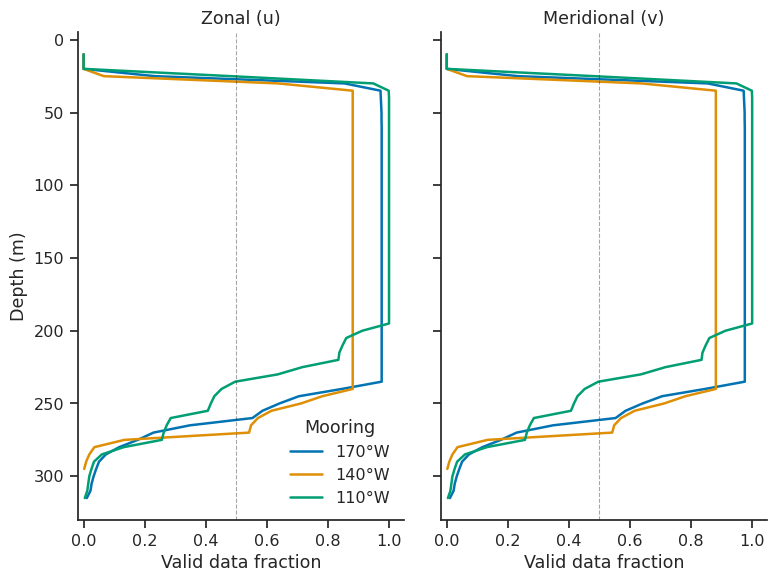

Saved: overview/data_coverage.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

for label, color in MOORING_COLORS.items():
    for ax, da in zip(axes, [u[label], v[label]]):
        # fraction of time steps with valid (non-NaN) data at each depth
        valid_frac = (~np.isnan(da.values)).mean(axis=0)
        ax.plot(valid_frac, da.depth.values, color=color, label=label, lw=1.8)

for ax, title in zip(axes, ['Zonal (u)', 'Meridional (v)']):
    ax.set_xlabel('Valid data fraction')
    ax.set_title(title)
    ax.set_xlim(-0.02, 1.05)
    ax.axvline(0.5, color='k', lw=0.8, ls='--', alpha=0.35)
    sns.despine(ax=ax)

axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()  # call once; sharey=True means all axes share the same y-axis
axes[0].legend(title='Mooring', frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'overview' / 'data_coverage.png', **SAVE_KW)
plt.show()
print('Saved: overview/data_coverage.png')

## 2 — Time-Depth Diagrams

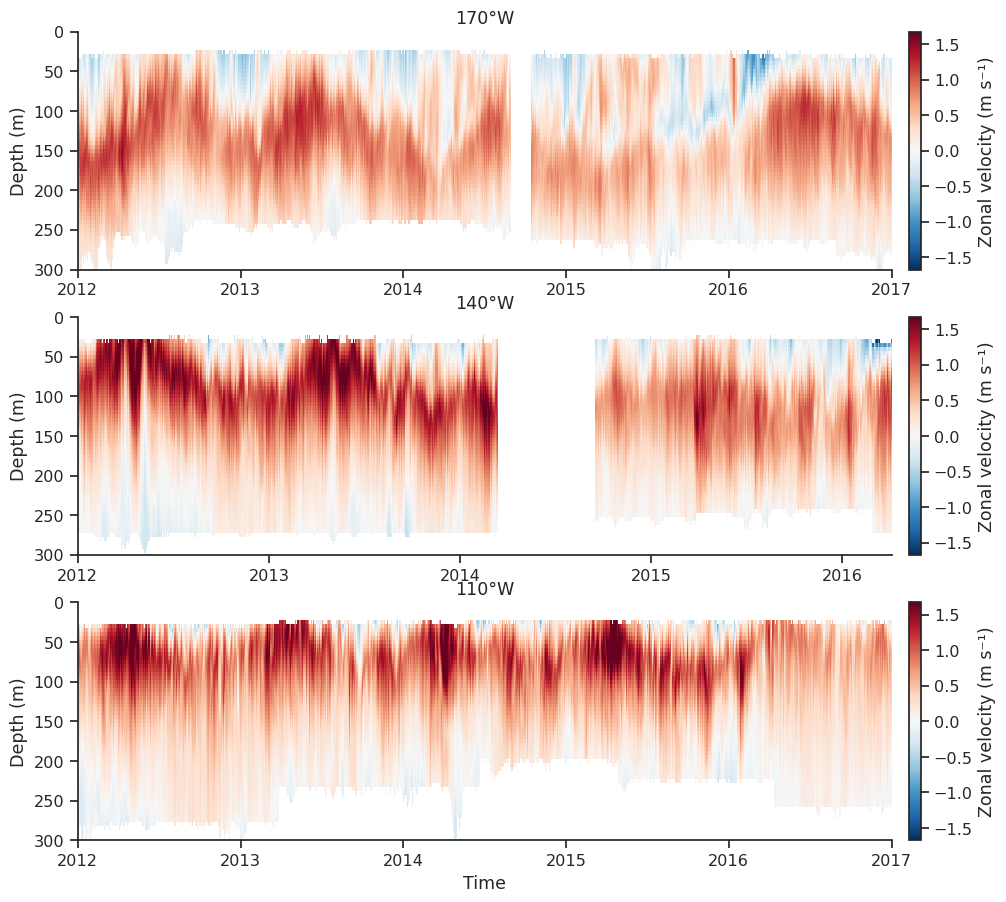

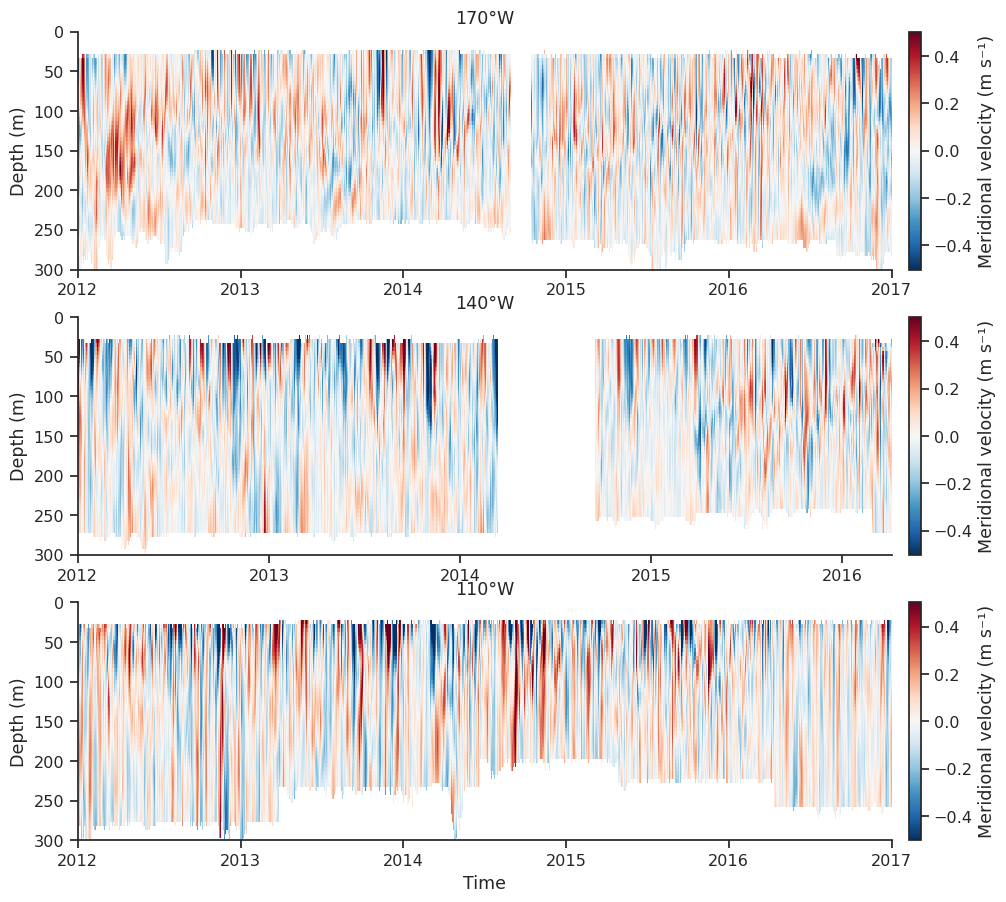

Saved: overview/timeseries_u.png, timeseries_v.png


In [7]:
def make_timeseries(data_dict, vmax, cbar_label):
    """Three-panel time-depth diagram, one row per mooring."""
    n = len(data_dict)
    fig, axes = plt.subplots(n, 1, figsize=(11, 3.5 * n), sharey=True)
    for ax, label in zip(axes, data_dict):
        da = data_dict[label]
        pcm = ax.pcolormesh(
            da.time.values, da.depth.values, da.values.T,
            cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto'
        )
        ax.set_ylabel('Depth (m)')
        ax.set_title(label)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        fig.colorbar(pcm, ax=ax, label=cbar_label, fraction=0.025, pad=0.02)
        sns.despine(ax=ax)
    axes[0].set_ylim(300, 0)  # clip below 300 m  # call once for shared y-axis
    axes[-1].set_xlabel('Time')
    return fig

# symmetric limits from 99th percentile of |values| across all moorings
u_vmax = max(float(np.nanpercentile(np.abs(da.values), 99)) for da in u.values())
v_vmax = max(float(np.nanpercentile(np.abs(da.values), 99)) for da in v.values())

fig = make_timeseries(u, u_vmax, 'Zonal velocity (m s⁻¹)')
fig.savefig(FIG_DIR / 'overview' / 'timeseries_u.png', **SAVE_KW)
plt.show()

fig = make_timeseries(v, v_vmax, 'Meridional velocity (m s⁻¹)')
fig.savefig(FIG_DIR / 'overview' / 'timeseries_v.png', **SAVE_KW)
plt.show()

print('Saved: overview/timeseries_u.png, timeseries_v.png')

## 3 — Time-Mean and Standard Deviation Profiles

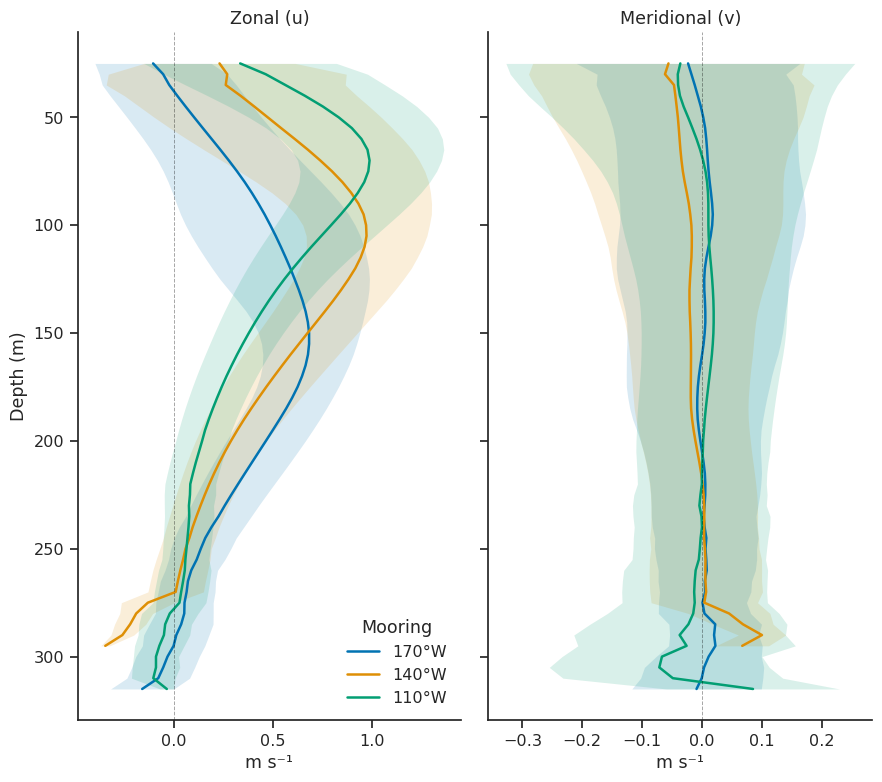

Saved: profiles/mean_std_profiles.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 8), sharey=True)

for label, color in MOORING_COLORS.items():
    for ax, da in zip(axes, [u[label], v[label]]):
        mean_prof = da.mean('time', skipna=True).values
        std_prof  = da.std('time',  skipna=True).values
        depths    = da.depth.values

        ax.plot(mean_prof, depths, color=color, label=label, lw=1.8)
        ax.fill_betweenx(depths, mean_prof - std_prof, mean_prof + std_prof,
                         color=color, alpha=0.15, linewidth=0)

for ax, title in zip(axes, ['Zonal (u)', 'Meridional (v)']):
    ax.set_xlabel('m s⁻¹')
    ax.set_title(title)
    ax.axvline(0, color='k', lw=0.7, ls='--', alpha=0.35)
    sns.despine(ax=ax)

axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()  # shared y-axis; call once
axes[0].legend(title='Mooring', frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'profiles' / 'mean_std_profiles.png', **SAVE_KW)
plt.show()
print('Saved: profiles/mean_std_profiles.png')

## 4 — Spatial Velocity Structure (Zonal Variation)
Time-mean computed over the common record period of all three moorings.

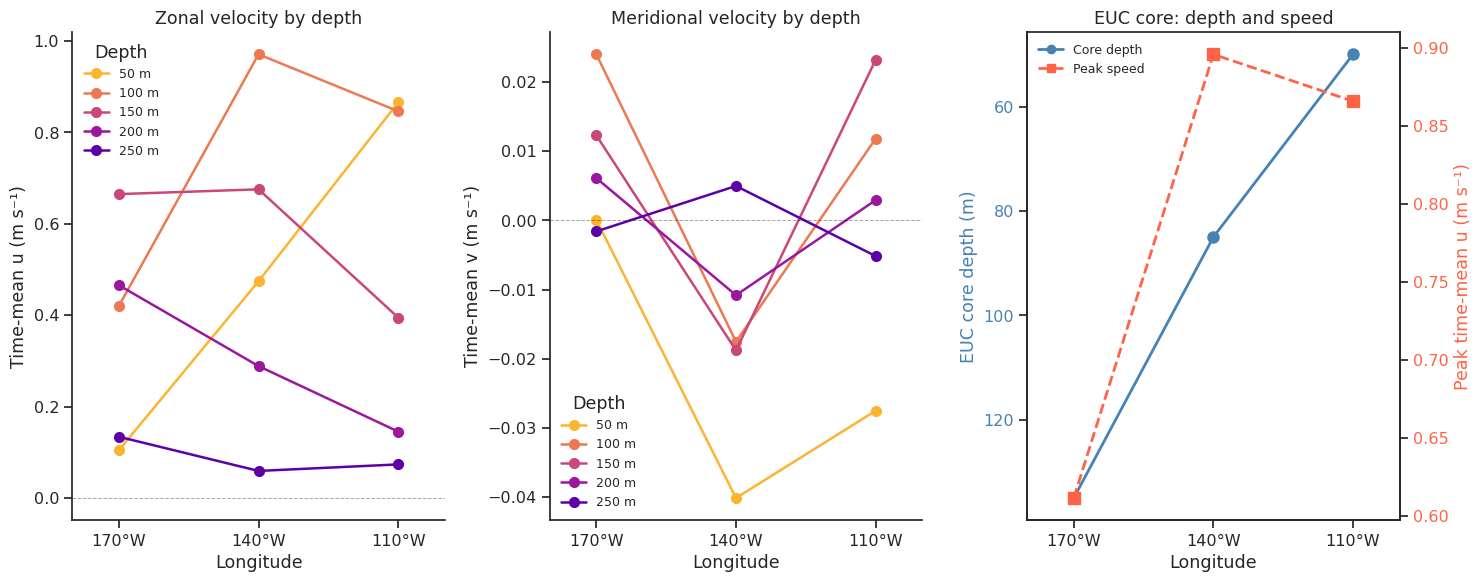

Saved: profiles/spatial_structure.png


In [9]:
from matplotlib.lines import Line2D

# common record period across all three moorings (limited by 140°W)
t_start = max(ds.time.values[0]  for ds in datasets.values())
t_end   = min(ds.time.values[-1] for ds in datasets.values())

# common depth levels present in all three moorings
d_common = np.intersect1d(
    np.intersect1d(datasets['170°W'].depth.values, datasets['140°W'].depth.values),
    datasets['110°W'].depth.values
)

# time-mean on common period, restricted to common depths
mean_u_sp = {
    label: u[label].sel(time=slice(t_start, t_end)).mean('time', skipna=True).sel(depth=d_common)
    for label in MOORINGS
}
mean_v_sp = {
    label: v[label].sel(time=slice(t_start, t_end)).mean('time', skipna=True).sel(depth=d_common)
    for label in MOORINGS
}

# EUC core: depth of maximum mean u, restricted to >= 30 m to avoid NaN-contaminated surface
euc_core_depth = {}
euc_core_speed = {}
for label in MOORINGS:
    mu = mean_u_sp[label].where(mean_u_sp[label].depth >= 30.0, drop=True).values.astype(float)
    mu[np.isnan(mu)] = -np.inf
    idx = int(np.argmax(mu))
    euc_core_depth[label] = float(mean_u_sp[label].depth.values[idx])
    val = mean_u_sp[label].values[idx]
    euc_core_speed[label] = float(val) if np.isfinite(val) else np.nan

# longitude in °W, ordered west to east; xlim set as (180, 100) to place 170°W on the left
LONS_W     = [170, 140, 110]
LON_LABELS = ['170°W', '140°W', '110°W']

SELECT_DEPTHS_SP = [50.0, 100.0, 150.0, 200.0, 250.0]
sp_colors = sns.color_palette('plasma_r', len(SELECT_DEPTHS_SP))

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Panels 1 and 2: mean u and v at selected depths vs longitude
for ax, mean_dict, ylabel, title in zip(
    axes[:2],
    [mean_u_sp, mean_v_sp],
    ['Time-mean u (m s⁻¹)', 'Time-mean v (m s⁻¹)'],
    ['Zonal velocity by depth', 'Meridional velocity by depth'],
):
    for d, color in zip(SELECT_DEPTHS_SP, sp_colors):
        vals = [
            float(mean_dict[label].sel(depth=d, method='nearest').values)
            if np.any(np.isclose(mean_dict[label].depth.values, d)) else np.nan
            for label in MOORINGS
        ]
        ax.plot(LONS_W, vals, 'o-', color=color, lw=1.8, ms=7, label=f'{d:.0f} m')

    ax.axhline(0, color='k', lw=0.7, ls='--', alpha=0.35)
    ax.set_xticks(LONS_W)
    ax.set_xticklabels(LON_LABELS)
    ax.set_xlim(180, 100)  # west on left (decreasing °W = moving east)
    ax.set_xlabel('Longitude')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Depth', frameon=False, fontsize=9)
    sns.despine(ax=ax)

# Panel 3: EUC core depth and peak speed vs longitude
ax3  = axes[2]
ax3b = ax3.twinx()

euc_d = [euc_core_depth[m] for m in MOORINGS]
euc_s = [euc_core_speed[m] for m in MOORINGS]

ax3.plot( LONS_W, euc_d, 'o-',  color='steelblue', lw=2.0, ms=8)
ax3b.plot(LONS_W, euc_s, 's--', color='tomato',    lw=2.0, ms=8)

ax3.set_xticks(LONS_W)
ax3.set_xticklabels(LON_LABELS)
ax3.set_xlim(180, 100)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('EUC core depth (m)',      color='steelblue')
ax3b.set_ylabel('Peak time-mean u (m s⁻¹)', color='tomato')
ax3.tick_params(axis='y', labelcolor='steelblue')
ax3b.tick_params(axis='y', labelcolor='tomato')
ax3.invert_yaxis()  # depth increases downward
ax3.set_title('EUC core: depth and speed')

ax3.legend(handles=[
    Line2D([0], [0], color='steelblue', marker='o',  lw=2.0, label='Core depth'),
    Line2D([0], [0], color='tomato',    marker='s', ls='--', lw=2.0, label='Peak speed'),
], frameon=False, fontsize=9)
sns.despine(ax=ax3, right=False)  # keep right spine for twin axis

plt.tight_layout()
fig.savefig(FIG_DIR / 'profiles' / 'spatial_structure.png', **SAVE_KW)
plt.show()
print('Saved: profiles/spatial_structure.png')

## 5 — Pearson Correlation and Covariance vs Depth
Each statistic computed over the overlapping time period for each mooring pair, using only co-valid samples at each depth. Solid: p < 0.05.

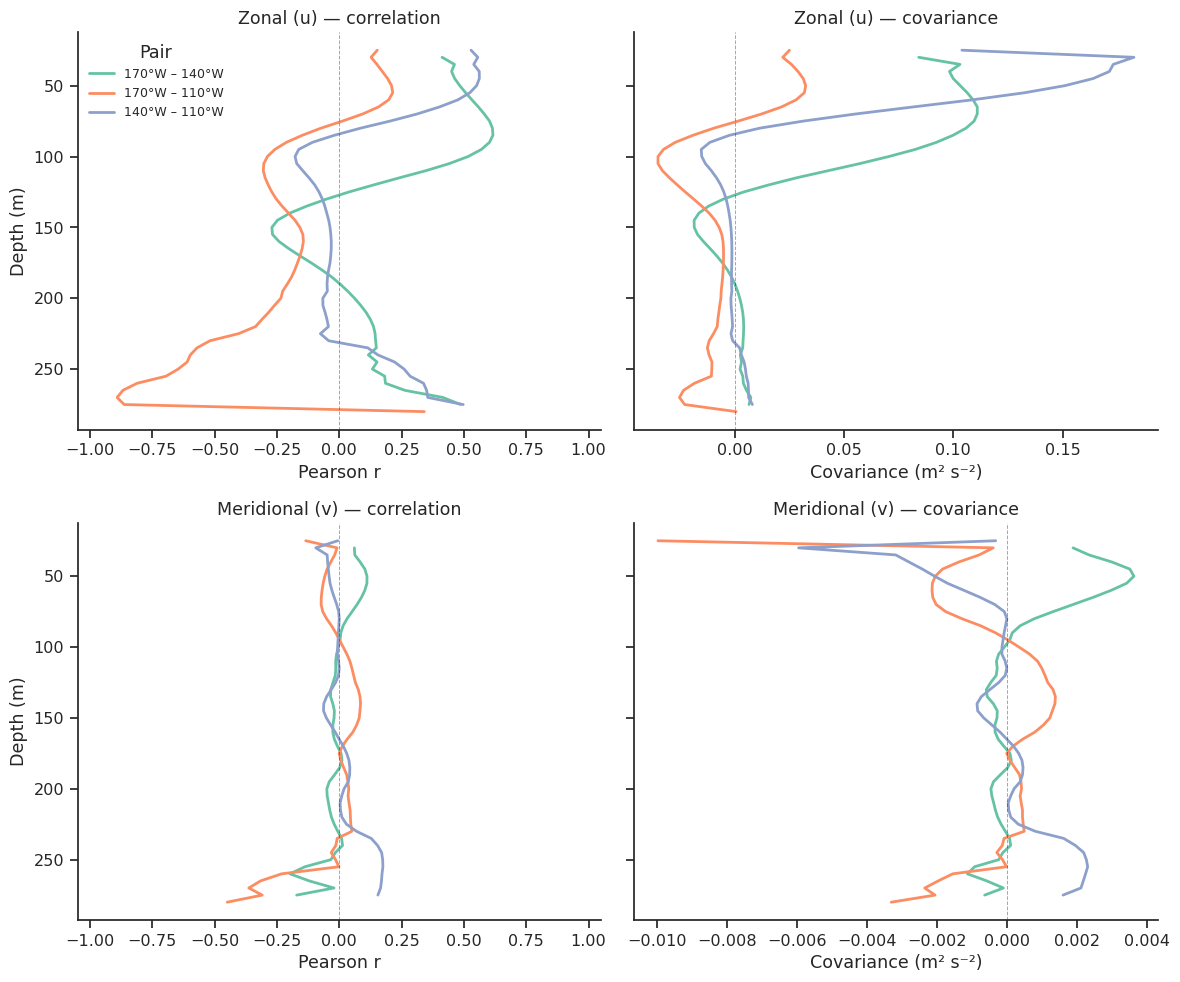

Saved: correlations/pearson_r_covariance_vs_depth.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for (m1, m2), pair_label, color, ls in zip(PAIRS, PAIR_LABELS, PAIR_COLORS, PAIR_LS):
    for row, data_dict in enumerate([u, v]):
        da1, da2 = data_dict[m1], data_dict[m2]

        depths_r, r_vals, _ = pearson_r_profile(da1, da2)
        depths_c, cov_vals  = covariance_profile(da1, da2)

        axes[row, 0].plot(r_vals,   depths_r, color=color, lw=2.0, ls=ls, label=pair_label)
        axes[row, 1].plot(cov_vals, depths_c, color=color, lw=2.0, ls=ls, label=pair_label)

row_labels = ["Zonal (u)", "Meridional (v)"]
for row, rl in enumerate(row_labels):
    axes[row, 0].set_xlabel("Pearson r")
    axes[row, 0].set_title(f"{rl} — correlation")
    axes[row, 0].set_xlim(-1.05, 1.05)
    axes[row, 0].axvline(0, color="k", lw=0.7, ls="--", alpha=0.35)
    axes[row, 0].set_ylabel("Depth (m)")

    axes[row, 1].set_xlabel("Covariance (m² s⁻²)")
    axes[row, 1].set_title(f"{rl} — covariance")
    axes[row, 1].axvline(0, color="k", lw=0.7, ls="--", alpha=0.35)

    for ax in axes[row]:
        sns.despine(ax=ax)

axes[0, 0].invert_yaxis()
axes[0, 0].legend(title="Pair", frameon=False, loc="upper left", fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / "correlations" / "pearson_r_covariance_vs_depth.png", **SAVE_KW)
plt.show()
print("Saved: correlations/pearson_r_covariance_vs_depth.png")

## 6 — Scatter Plots at Selected Depths
Color encodes time (sequential within each pair's overlapping record). Red line: OLS regression.

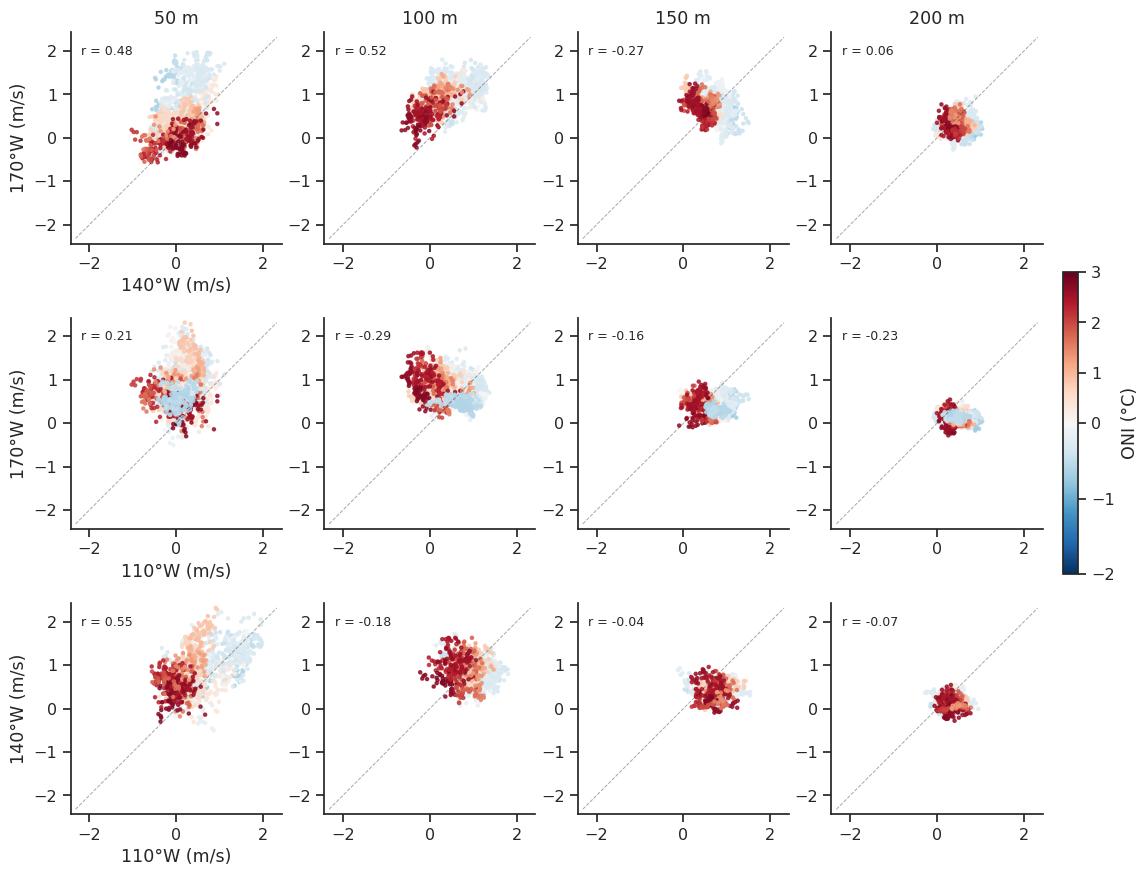

Saved: correlations/scatter_u.png


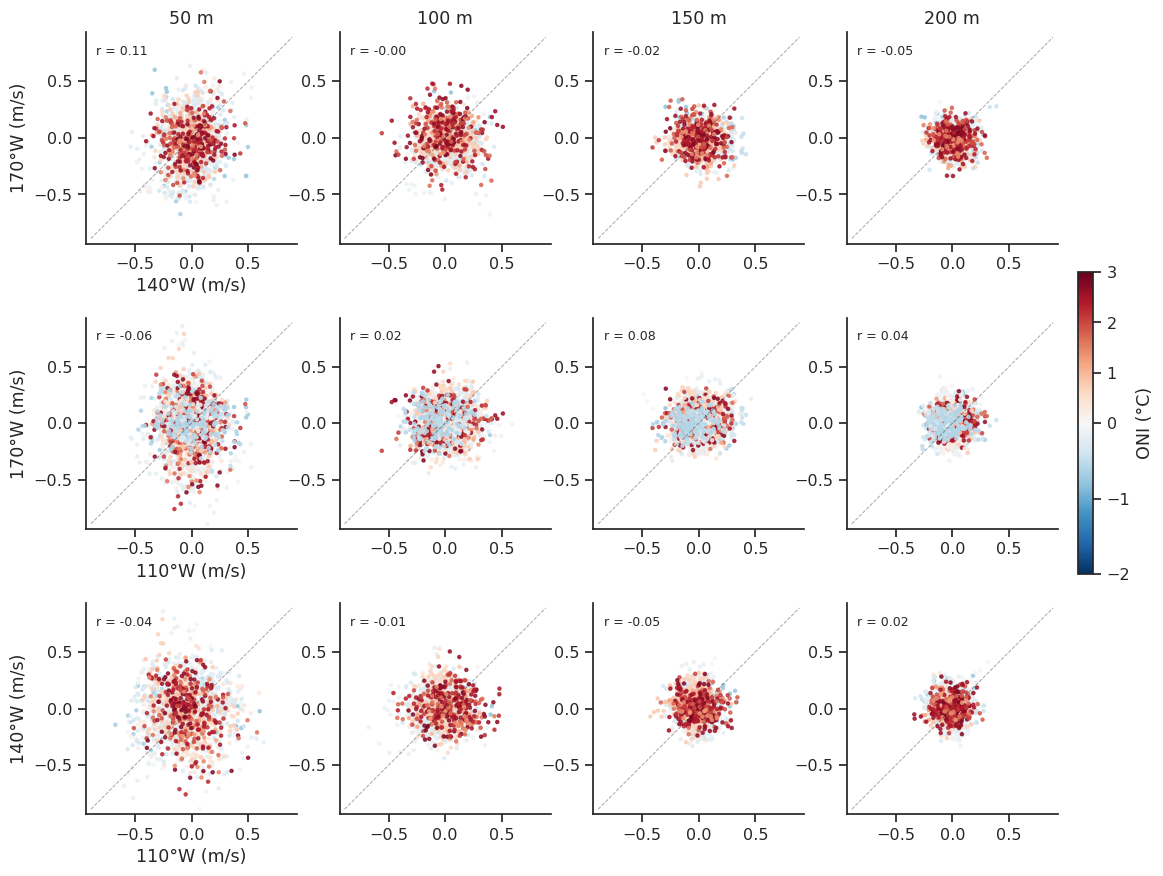

Saved: correlations/scatter_v.png


In [11]:
SELECT_DEPTHS = [50.0, 100.0, 150.0, 200.0]

for comp, data_dict, fname in [
    ('Zonal (u)',      u, 'scatter_u.png'),
    ('Meridional (v)', v, 'scatter_v.png'),
]:
    all_vals = []
    for m1, m2 in PAIRS:
        a1, a2, _, d_common = align_pair(data_dict[m1], data_dict[m2])
        for d in SELECT_DEPTHS:
            if not np.any(np.isclose(d_common, d)): continue
            d_idx = np.argmin(np.abs(d_common - d))
            x = a1.isel(depth=d_idx).values.astype(float)
            y = a2.isel(depth=d_idx).values.astype(float)
            m = np.isfinite(x) & np.isfinite(y)
            if m.sum() > 0:
                all_vals.extend(np.abs(x[m]).tolist())
                all_vals.extend(np.abs(y[m]).tolist())
    global_lim = float(np.nanmax(np.abs(all_vals))) if all_vals else 1.0

    fig, axes = plt.subplots(len(PAIRS), len(SELECT_DEPTHS),
                             figsize=(13, 3.5 * len(PAIRS)))

    for row, (m1, m2) in enumerate(PAIRS):
        da1, da2 = data_dict[m1], data_dict[m2]
        a1, a2, t_common, d_common = align_pair(da1, da2)
        oni_at_common = get_oni(t_common)

        for col, d in enumerate(SELECT_DEPTHS):
            ax = axes[row, col]

            # structural labels — title on row 0; both axis labels on col 0
            if row == 0:
                ax.set_title(f'{d:.0f} m')
            if col == 0:
                ax.set_ylabel(f'{m1} (m/s)')
                ax.set_xlabel(f'{m2} (m/s)')

            no_depth = not np.any(np.isclose(d_common, d))
            if no_depth:
                for sp in ax.spines.values(): sp.set_visible(False)
                ax.set_xticks([]); ax.set_yticks([])
                continue

            d_idx = np.argmin(np.abs(d_common - d))
            x = a1.isel(depth=d_idx).values.astype(float)
            y = a2.isel(depth=d_idx).values.astype(float)
            m = np.isfinite(x) & np.isfinite(y)

            if m.sum() < 10:
                for sp in ax.spines.values(): sp.set_visible(False)
                ax.set_xticks([]); ax.set_yticks([])
                continue

            ax.scatter(x[m], y[m], c=oni_at_common[m],
                       cmap=ONI_CMAP, norm=ONI_NORM, s=5, alpha=0.8, rasterized=True)
            r = stats.linregress(x[m], y[m]).rvalue
            ax.text(0.05, 0.94, f'r = {r:.2f}',
                    transform=ax.transAxes, va='top', fontsize=9)
            ax.plot([-global_lim, global_lim], [-global_lim, global_lim],
                    'k--', lw=0.7, alpha=0.35)
            ax.set_xlim(-global_lim * 1.05, global_lim * 1.05)
            ax.set_ylim(-global_lim * 1.05, global_lim * 1.05)
            ax.set_aspect('equal')
            sns.despine(ax=ax)

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(cmap=ONI_CMAP, norm=ONI_NORM),
        ax=axes, orientation='vertical', fraction=0.015, pad=0.02
    )
    cbar.set_label('ONI (°C)')
    cbar.set_ticks([-2, -1, 0, 1, 2, 3])
    plt.savefig(FIG_DIR / 'correlations' / fname, **SAVE_KW)
    plt.show()
    print(f'Saved: correlations/{fname}')


## 7 — Lagged Cross-Correlation
Positive lag means mooring 1 leads mooring 2. NaN gaps zero-filled after demeaning.

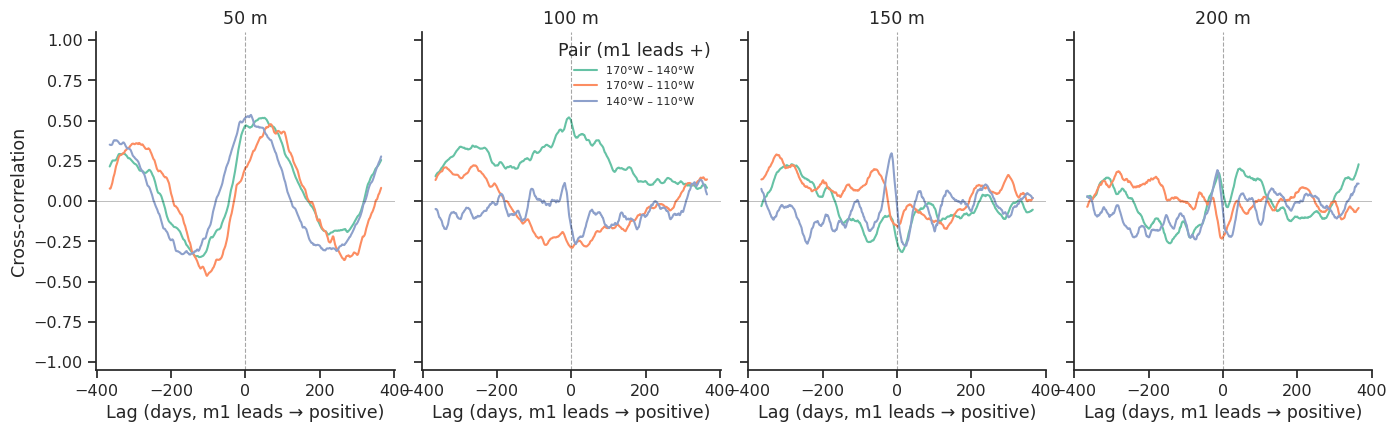

Saved: cross_correlation/lagged_xcorr_u.png


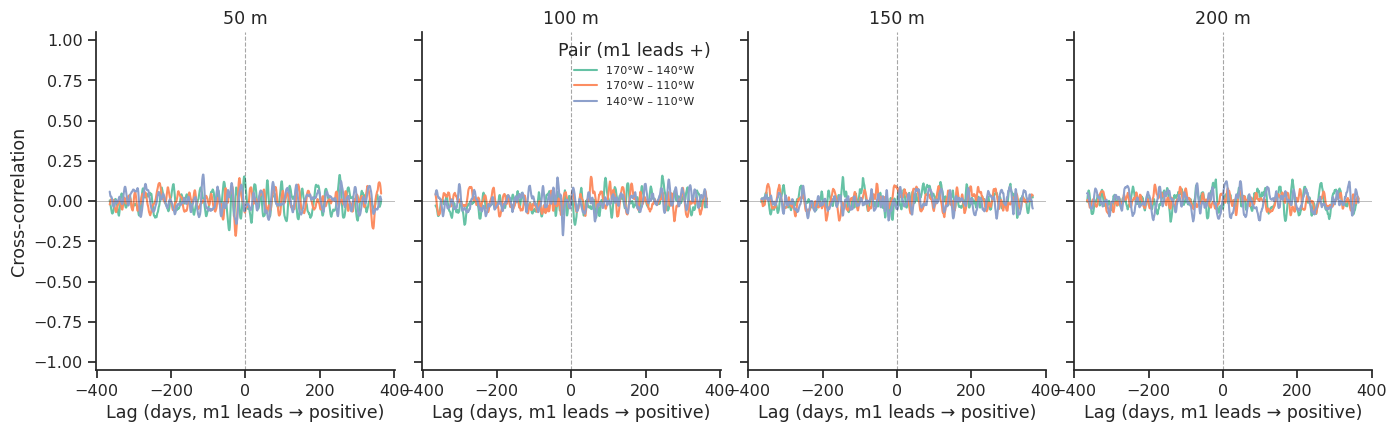

Saved: cross_correlation/lagged_xcorr_v.png


In [12]:
SELECT_DEPTHS_XC = [50.0, 100.0, 150.0, 200.0]

for comp, data_dict, fname in [
    ("Zonal (u)",     u, "lagged_xcorr_u.png"),
    ("Meridional (v)", v, "lagged_xcorr_v.png"),
]:
    fig, axes = plt.subplots(1, len(SELECT_DEPTHS_XC), figsize=(14, 4.5), sharey=True)
    for col, d in enumerate(SELECT_DEPTHS_XC):
        ax = axes[col]
        for (m1, m2), pair_label, color, ls in zip(PAIRS, PAIR_LABELS, PAIR_COLORS, PAIR_LS):
            lags, xcorr = lagged_xcorr(data_dict[m1], data_dict[m2], d)
            if lags is not None:
                ax.plot(lags, xcorr, color=color, lw=1.5, ls=ls, label=pair_label)
        ax.axhline(0, color="k", lw=0.6, alpha=0.3)
        ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.35)
        ax.set_xlabel("Lag (days, m1 leads → positive)")
        ax.set_title(f"{d:.0f} m")
        ax.set_ylim(-1.05, 1.05)
        sns.despine(ax=ax)
    axes[0].set_ylabel("Cross-correlation")
    from matplotlib.lines import Line2D as _L2D
    _leg_h = [_L2D([0],[0], color=c, lw=1.5, ls=s, label=l)
              for l, c, s in zip(PAIR_LABELS, PAIR_COLORS, PAIR_LS)]
    axes[1].legend(handles=_leg_h, title="Pair (m1 leads +)", frameon=False, fontsize=8)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "cross_correlation" / fname, **SAVE_KW)
    plt.show()
    print(f"Saved: cross_correlation/{fname}")

## 8 — Velocity Hodographs (u′ vs v′)
Anomalies relative to the time-mean at each depth. The shape of the scatter cloud (aspect ratio, orientation) indicates the polarization of the dominant variability. The dashed ellipse is the 1-sigma variance ellipse from the eigendecomposition of the u′–v′ covariance matrix; σᵤ/σᵥ > 1 implies zonal-dominant variability.

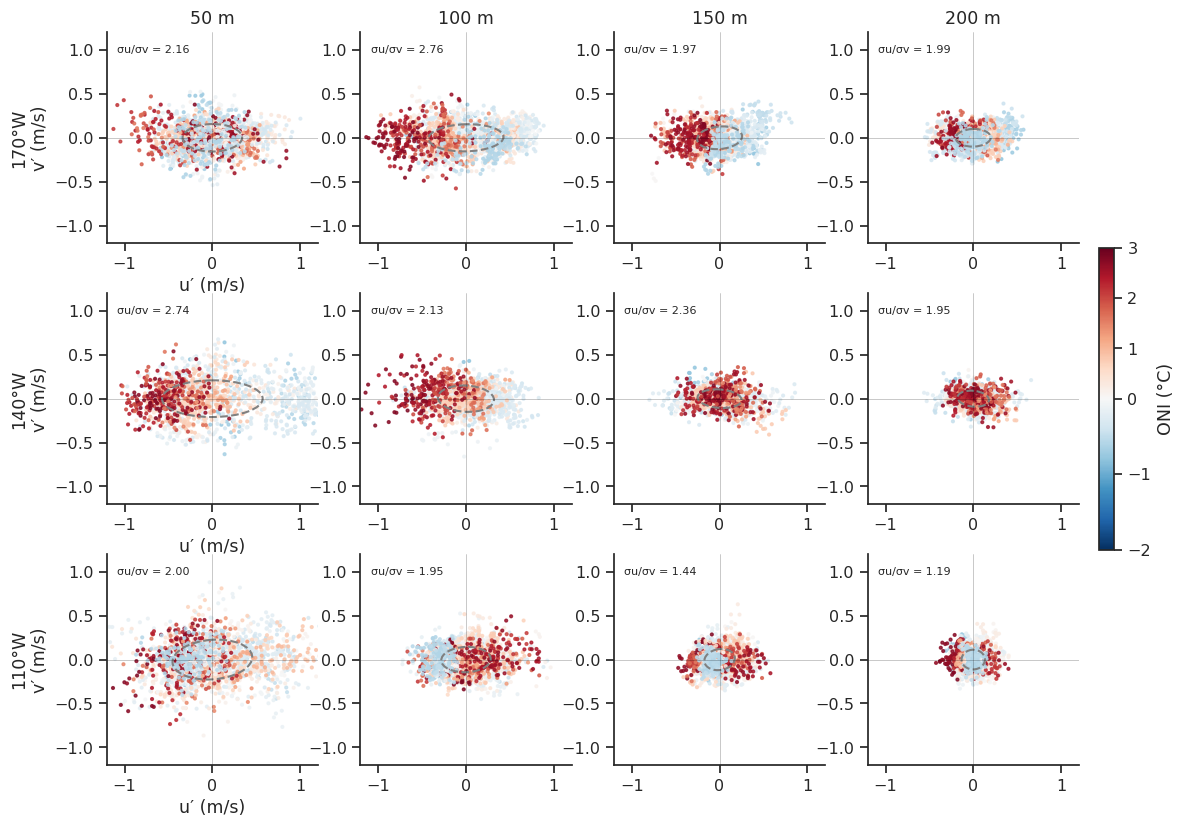

Saved: correlations/hodograph_uv.png


In [13]:
from matplotlib.patches import Ellipse

SELECT_DEPTHS_HOD = [50.0, 100.0, 150.0, 200.0]

global_lim_hod = 0.0
for _lbl in MOORINGS:
    for _d in SELECT_DEPTHS_HOD:
        if not (np.any(np.isclose(u[_lbl].depth.values, _d)) and
                np.any(np.isclose(v[_lbl].depth.values, _d))):
            continue
        _ut = u[_lbl].sel(depth=_d, method='nearest').values.astype(float)
        _vt = v[_lbl].sel(depth=_d, method='nearest').values.astype(float)
        _m  = np.isfinite(_ut) & np.isfinite(_vt)
        if _m.sum() >= 10:
            global_lim_hod = max(global_lim_hod, np.nanpercentile(
                np.abs(np.concatenate([_ut[_m] - _ut[_m].mean(),
                                       _vt[_m] - _vt[_m].mean()])), 99))

fig, axes = plt.subplots(len(MOORINGS), len(SELECT_DEPTHS_HOD),
                         figsize=(13, 3.2 * len(MOORINGS)))

for row, label in enumerate(MOORINGS):
    da_u = u[label]
    da_v = v[label]
    oni_vals = get_oni(da_u.time.values)

    for col, d in enumerate(SELECT_DEPTHS_HOD):
        ax = axes[row, col]

        # structural labels — title on row 0; both axis labels on col 0
        if row == 0:
            ax.set_title(f'{d:.0f} m')
        if col == 0:
            ax.set_ylabel(f'{label}\nv\u2032 (m/s)')
            ax.set_xlabel("u\u2032 (m/s)")

        has_u = np.any(np.isclose(da_u.depth.values, d))
        has_v = np.any(np.isclose(da_v.depth.values, d))
        if not (has_u and has_v):
            for sp in ax.spines.values(): sp.set_visible(False)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        u_t = da_u.sel(depth=d, method='nearest').values.astype(float)
        v_t = da_v.sel(depth=d, method='nearest').values.astype(float)
        m = np.isfinite(u_t) & np.isfinite(v_t)

        if m.sum() < 10:
            for sp in ax.spines.values(): sp.set_visible(False)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        u_anom = u_t - np.nanmean(u_t[m])
        v_anom = v_t - np.nanmean(v_t[m])

        ax.scatter(u_anom[m], v_anom[m], c=oni_vals[m],
                   cmap=ONI_CMAP, norm=ONI_NORM, s=4, alpha=0.8, rasterized=True)

        cov_mat = np.cov(u_anom[m], v_anom[m])
        eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
        w = 2 * np.sqrt(np.abs(eigenvalues[1]))
        h = 2 * np.sqrt(np.abs(eigenvalues[0]))
        angle = np.degrees(np.arctan2(*eigenvectors[:, 1][::-1]))
        ax.add_patch(Ellipse(xy=(0, 0), width=w, height=h, angle=angle,
                             fc='none', ec='gray', lw=1.5, ls='--'))

        ax.set_xlim(-global_lim_hod, global_lim_hod)
        ax.set_ylim(-global_lim_hod, global_lim_hod)
        ax.set_aspect('equal')
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.axvline(0, color='k', lw=0.5, alpha=0.3)

        ratio = np.std(u_anom[m]) / np.std(v_anom[m])
        ax.text(0.05, 0.94, f'\u03c3u/\u03c3v = {ratio:.2f}',
                transform=ax.transAxes, va='top', fontsize=8)
        sns.despine(ax=ax)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=ONI_CMAP, norm=ONI_NORM),
    ax=axes, orientation='vertical', fraction=0.015, pad=0.02
)
cbar.set_label('ONI (\u00b0C)')
cbar.set_ticks([-2, -1, 0, 1, 2, 3])
plt.savefig(FIG_DIR / 'correlations' / 'hodograph_uv.png', **SAVE_KW)
plt.show()
print('Saved: correlations/hodograph_uv.png')


In [14]:

import scipy.ndimage as _ndimage
import matplotlib.dates as _mdates
from matplotlib.ticker import FuncFormatter as _FmtFn

(FIG_DIR / 'wavelet_coherence').mkdir(exist_ok=True)


def _morlet_cwt(x, scales, omega0=6.0):
    n = len(x)
    N = int(2 ** np.ceil(np.log2(n + 1)))
    Xf = np.fft.fft(np.append(x - x.mean(), np.zeros(N - n)))
    k  = np.fft.fftfreq(N) * 2 * np.pi
    W  = np.empty((len(scales), n), dtype=complex)
    for i, s in enumerate(scales):
        psi = np.sqrt(2 * np.pi * s) * np.pi**(-0.25) * np.exp(-0.5 * (s * k - omega0) ** 2)
        psi[k <= 0] = 0
        W[i] = np.fft.ifft(Xf * psi)[:n]
    return W


def wavelet_coherence(x, y, omega0=6.0, nvoice=12):
    """Squared wavelet coherence (Morlet). Periods span 20 d to min(2 yr, N/4).
    COI and NaN input positions are masked (returned as NaN)."""
    n = len(x)
    ff    = (4 * np.pi) / (omega0 + np.sqrt(2 + omega0 ** 2))
    s0    = 20.0 / ff
    s_max = min(730.0, n / 4) / ff
    n_sc  = int(np.log2(s_max / s0) * nvoice) + 1
    scales  = s0 * 2 ** (np.arange(n_sc) / nvoice)
    periods = scales * ff

    mx, my = np.isfinite(x), np.isfinite(y)
    xf = np.where(mx, x, np.nanmean(x) if mx.any() else 0.0)
    yf = np.where(my, y, np.nanmean(y) if my.any() else 0.0)
    Wx  = _morlet_cwt(xf, scales, omega0)
    Wy  = _morlet_cwt(yf, scales, omega0)
    Wxy = Wx * np.conj(Wy)

    Wxy_sm = np.empty_like(Wxy)
    Wxx_sm = np.empty(Wxy.shape, dtype=float)
    Wyy_sm = np.empty(Wxy.shape, dtype=float)
    for i, s in enumerate(scales):
        sig = max(0.6 * s, 0.5)
        Wxy_sm[i] = (_ndimage.gaussian_filter1d(Wxy[i].real, sig) +
                     1j * _ndimage.gaussian_filter1d(Wxy[i].imag, sig))
        Wxx_sm[i] = _ndimage.gaussian_filter1d(np.abs(Wx[i]) ** 2, sig)
        Wyy_sm[i] = _ndimage.gaussian_filter1d(np.abs(Wy[i]) ** 2, sig)
    sw     = max(1, int(0.6 * nvoice))
    Wxy_sm = (_ndimage.uniform_filter1d(Wxy_sm.real, sw, axis=0) +
               1j * _ndimage.uniform_filter1d(Wxy_sm.imag, sw, axis=0))
    Wxx_sm = _ndimage.uniform_filter1d(Wxx_sm, sw, axis=0)
    Wyy_sm = _ndimage.uniform_filter1d(Wyy_sm, sw, axis=0)

    wtc   = np.clip(np.abs(Wxy_sm) ** 2 / (Wxx_sm * Wyy_sm + 1e-20), 0, 1)
    phase = np.angle(Wxy_sm)

    t   = np.arange(n)
    coi = ff * np.sqrt(2) * np.minimum(t, n - 1 - t)
    wtc[periods[:, None] > coi[None, :]] = np.nan
    wtc[:, (~mx) | (~my)] = np.nan
    phase[np.isnan(wtc)] = np.nan
    return wtc, phase, periods, coi


def _wtc_panel(ax, t_dt64, wtc, phase, periods, coi,
               col_title='', row_label='',
               first_col=False, last_row=False, draw_title=False, yr_step=1):
    """Draw one WTC panel: high-coherence regions in magma, low-coh dark, COI opaque."""
    tf = _mdates.date2num(t_dt64.astype('datetime64[ms]').astype('O'))
    T, P = np.meshgrid(tf, periods)

    # Dark background for inside-COI, low-coherence regions
    ax.pcolormesh(T, P, np.where(np.isfinite(wtc), 1.0, np.nan),
                   cmap='Greys', vmin=0, vmax=1, shading='auto', zorder=0)

    # High-coherence signal (>= 0.5) in magma
    _cmap = plt.cm.viridis.copy()
    _cmap.set_bad(color='none')
    wtc_hi = np.where(np.isfinite(wtc) & (wtc >= 0.5), wtc, np.nan)
    im = ax.pcolormesh(T, P, wtc_hi, cmap=_cmap,
                        vmin=0.5, vmax=1.0, shading='auto', zorder=1)

    ax.set_yscale('log')
    ax.set_ylim(periods.min(), periods.max())
    ax.xaxis_date()

    # COI fully opaque
    coi_p = np.clip(coi, periods.min(), periods.max())
    ax.fill_between(t_dt64.astype('datetime64[ms]').astype('O'),
                    coi_p, periods.max(), color='0.5', alpha=1.0, lw=0, zorder=2)

    # Period axis — named ticks only
    yticks = [v for v in [20, 32, 64, 128, 256, 365, 730]
              if periods.min() <= v <= periods.max()]
    ax.set_yticks(yticks)
    ax.yaxis.set_minor_locator(plt.NullLocator())
    if first_col:
        lbl = (row_label + '\nPeriod (days)') if row_label else 'Period (days)'
        ax.set_ylabel(lbl, fontsize=7)
        ax.yaxis.set_major_formatter(
            _FmtFn(lambda v, _: (f'{int(v)}d' if v < 365 else f'{v/365:.1f}yr')))
    else:
        ax.yaxis.set_major_formatter(_FmtFn(lambda v, _: ''))

    if last_row:
        ax.xaxis.set_major_locator(_mdates.YearLocator(yr_step))
        ax.xaxis.set_major_formatter(_mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', labelsize=7)
        ax.set_xlabel('Time', fontsize=7)
    else:
        ax.xaxis.set_major_formatter(_FmtFn(lambda v, _: ''))

    if draw_title:
        ax.set_title(col_title, fontsize=8)
    sns.despine(ax=ax)
    return im


In [15]:

SELECT_DEPTHS_WTC = [50.0, 100.0, 150.0, 200.0]
_YR = 5 if 'full_record' in str(FIG_DIR) else 1

for _comp, _data in [('u', u), ('v', v)]:
    for focal in MOORINGS:
        others   = [m for m in MOORINGS if m != focal]
        n_r, n_c = len(others), len(SELECT_DEPTHS_WTC)
        fig, axes = plt.subplots(n_r, n_c, figsize=(4.2 * n_c, 3.2 * n_r), squeeze=False, constrained_layout=True)
        _im = None
        for row, other in enumerate(others):
            da1, da2 = _data[focal], _data[other]
            t_common = np.intersect1d(da1.time.values, da2.time.values)
            for col, d in enumerate(SELECT_DEPTHS_WTC):
                ax = axes[row, col]
                if row == 0:
                    ax.set_title(f'{d:.0f} m', fontsize=9)
                d1ok = np.any(np.isclose(da1.depth.values, d))
                d2ok = np.any(np.isclose(da2.depth.values, d))
                if not (d1ok and d2ok):
                    for sp in ax.spines.values(): sp.set_visible(False)
                    ax.set_xticks([]); ax.set_yticks([])
                    if col == 0:
                        ax.set_ylabel(f'{focal} vs {other}\nPeriod (days)', fontsize=7)
                    ax.set_xlabel('Time', fontsize=7)
                    continue
                x = da1.sel(time=t_common, depth=d, method='nearest').values.astype(float)
                y = da2.sel(time=t_common, depth=d, method='nearest').values.astype(float)
                if np.isfinite(x).sum() < 100:
                    for sp in ax.spines.values(): sp.set_visible(False)
                    ax.set_xticks([]); ax.set_yticks([])
                    if col == 0:
                        ax.set_ylabel(f'{focal} vs {other}\nPeriod (days)', fontsize=7)
                    ax.set_xlabel('Time', fontsize=7)
                    continue
                wtc, phase, periods, coi = wavelet_coherence(x, y)
                _im = _wtc_panel(ax, t_common, wtc, phase, periods, coi,
                                  col_title=f'{d:.0f} m',
                                  row_label=f'{focal} vs {other}',
                                  first_col=(col == 0),
                                  last_row=True,
                                  draw_title=(row == 0),
                                  yr_step=_YR)
        if _im is not None:
            cb = fig.colorbar(_im, ax=axes, fraction=0.015, pad=0.02)
            cb.set_label('Coherence'); cb.set_ticks([0, .25, .5, .75, 1])
        _safe = focal.replace('°', '').replace(' ', '_')
        _fn   = f'wavelet_coherence_{_comp}_{_safe}.png'
        fig.suptitle(f'Wavelet Coherence — {focal}, {_comp.upper()}', fontsize=10, y=1.01)
        fig.savefig(FIG_DIR / 'wavelet_coherence' / _fn, **SAVE_KW)
        plt.close()
        print(f'Saved: wavelet_coherence/{_fn}')


Saved: wavelet_coherence/wavelet_coherence_u_170W.png


Saved: wavelet_coherence/wavelet_coherence_u_140W.png


Saved: wavelet_coherence/wavelet_coherence_u_110W.png


Saved: wavelet_coherence/wavelet_coherence_v_170W.png


Saved: wavelet_coherence/wavelet_coherence_v_140W.png


Saved: wavelet_coherence/wavelet_coherence_v_110W.png


In [16]:

from scipy.signal.windows import hann as _hann

(FIG_DIR / 'cross_spectral').mkdir(exist_ok=True)

# Mooring longitudes (decimal degrees east)
_LON = {}
for _m in MOORINGS:
    if '°W' in _m:
        _LON[_m] = -float(_m.replace('°W', ''))
    elif '°E' in _m:
        _LON[_m] = float(_m.replace('°E', ''))

# Eastward separation (m): positive = m2 is east of m1 (wraps date line)
PAIR_SEP_M = {}
for _m1, _m2 in PAIRS:
    _dl = _LON[_m2] - _LON[_m1]
    if _dl > 180:  _dl -= 360
    if _dl < -180: _dl += 360
    PAIR_SEP_M[(_m1, _m2)] = _dl * 111_320.0


def _max_gap(valid_mask):
    """Length of the longest consecutive-NaN run."""
    if valid_mask.all(): return 0
    d = np.diff(np.concatenate([[1], valid_mask.astype(int), [1]]))
    starts = np.where(d == -1)[0]; ends = np.where(d == 1)[0]
    return int((ends - starts).max()) if len(starts) else 0


def cross_spectral_welch(x, y, seg_days=730, overlap=0.5, max_gap=14):
    """
    Welch cross-spectral coherence between daily time series x, y.

    Gaps <= max_gap days are linearly interpolated per segment.
    Segments containing longer gaps are skipped.

    Returns: (periods_days, coh2, phase_rad, n_segs)
    - periods: 1/freq, days
    - coh2: coherence squared [0, 1]
    - phase: positive = x leads y
    Returns (None, None, None, 0) if fewer than 2 valid segments.
    """
    n = len(x); L = int(seg_days); step = int(L * (1 - overlap))
    win = _hann(L); win_ss = win @ win

    Sxx = np.zeros(L // 2 + 1)
    Syy = np.zeros(L // 2 + 1)
    Sxy = np.zeros(L // 2 + 1, dtype=complex)
    n_segs = 0

    for s in range(0, n - L + 1, step):
        xs = x[s:s+L].copy().astype(float)
        ys = y[s:s+L].copy().astype(float)
        mx = np.isfinite(xs); my = np.isfinite(ys)

        if _max_gap(mx) > max_gap or _max_gap(my) > max_gap:
            continue

        t = np.arange(L, dtype=float)
        if not mx.all(): xs = np.interp(t, t[mx], xs[mx])
        if not my.all(): ys = np.interp(t, t[my], ys[my])

        xs -= np.polyval(np.polyfit(t, xs, 1), t); xs *= win
        ys -= np.polyval(np.polyfit(t, ys, 1), t); ys *= win

        Xf = np.fft.rfft(xs); Yf = np.fft.rfft(ys)
        Sxy += Xf * np.conj(Yf)
        Sxx += (Xf * np.conj(Xf)).real
        Syy += (Yf * np.conj(Yf)).real
        n_segs += 1

    if n_segs < 2:
        return None, None, None, 0

    freqs = np.fft.rfftfreq(L, d=1.0)[1:]       # skip DC
    coh2  = np.clip(np.abs(Sxy[1:] / n_segs) ** 2 /
                    (Sxx[1:] * Syy[1:] / n_segs ** 2 + 1e-30), 0, 1)
    phase = np.angle(Sxy[1:])
    return 1.0 / freqs, coh2, phase, n_segs


def coh2_thresh(n_segs, alpha=0.05):
    """Coherence² significance threshold for K-segment Welch estimate."""
    return 1.0 - alpha ** (1.0 / (n_segs - 1))


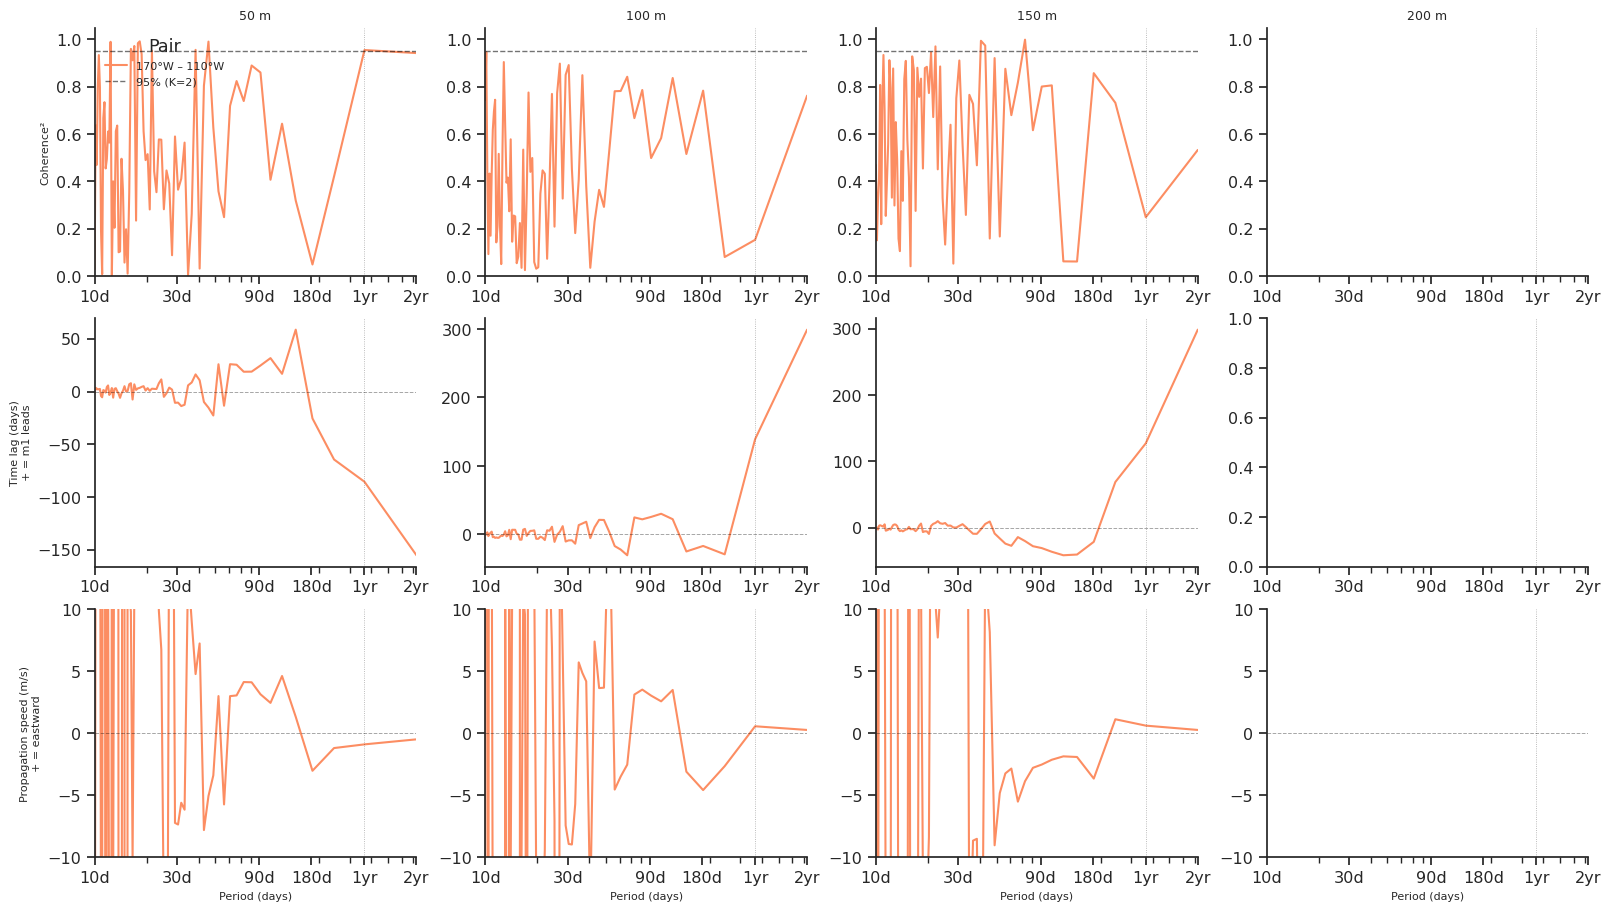

Saved: cross_spectral/cross_spectral_u.png


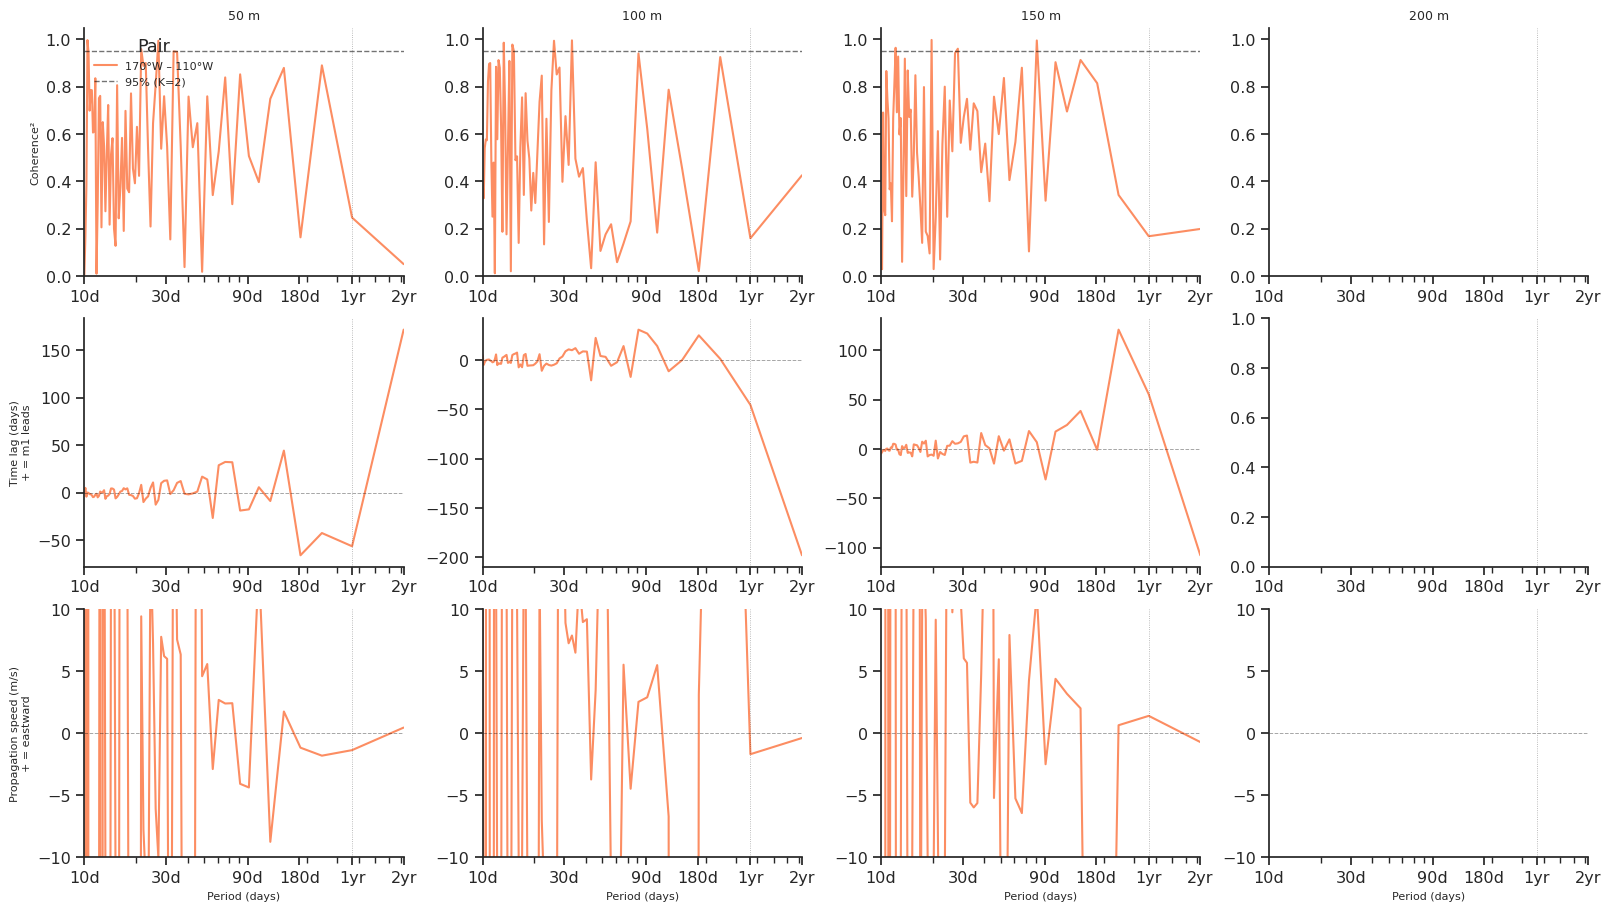

Saved: cross_spectral/cross_spectral_v.png


In [17]:

SELECT_DEPTHS_CS = [50.0, 100.0, 150.0, 200.0]
PMIN, PMAX = 10.0, 730.0   # period range (days) to display

_PTICKS = [10, 30, 90, 180, 365, 730]

for comp, data_dict, fname in [('u', u, 'cross_spectral_u.png'),
                                 ('v', v, 'cross_spectral_v.png')]:
    fig, axes = plt.subplots(3, len(SELECT_DEPTHS_CS),
                              figsize=(4.0 * len(SELECT_DEPTHS_CS), 9),
                              constrained_layout=True)

    for col, d in enumerate(SELECT_DEPTHS_CS):
        ax_c  = axes[0, col]   # coherence²
        ax_t  = axes[1, col]   # time lag (days)
        ax_sp = axes[2, col]   # propagation speed (m/s)

        ax_c.set_title(f'{d:.0f} m', fontsize=9)
        if col == 0:
            ax_c.set_ylabel('Coherence²', fontsize=8)
            ax_t.set_ylabel('Time lag (days)\n+ = m1 leads', fontsize=8)
            ax_sp.set_ylabel('Propagation speed (m/s)\n+ = eastward', fontsize=8)
        ax_sp.set_xlabel('Period (days)', fontsize=8)

        _thresh_drawn = False
        for (m1, m2), pair_label, color, ls in zip(PAIRS, PAIR_LABELS, PAIR_COLORS, PAIR_LS):
            da1, da2 = data_dict[m1], data_dict[m2]
            t_common = np.intersect1d(da1.time.values, da2.time.values)
            if not (np.any(np.isclose(da1.depth.values, d)) and
                    np.any(np.isclose(da2.depth.values, d))):
                continue
            x = da1.sel(time=t_common, depth=d, method='nearest').values.astype(float)
            y = da2.sel(time=t_common, depth=d, method='nearest').values.astype(float)

            periods, coh2, phase, n_segs = cross_spectral_welch(x, y)
            if periods is None:
                continue

            mask = (periods >= PMIN) & (periods <= PMAX)
            p  = periods[mask][::-1]   # sort ascending period
            c  = coh2[mask][::-1]
            ph = phase[mask][::-1]

            lag_days = ph * p / (2 * np.pi)                       # + = m1 leads
            sep_m    = PAIR_SEP_M.get((m1, m2), np.nan)
            speed_ms = sep_m / (lag_days * 86_400 + 1e-30)        # m/s

            ax_c.plot(p, c,        color=color, lw=1.5, ls=ls, label=pair_label)
            ax_t.plot(p, lag_days, color=color, lw=1.5, ls=ls)
            ax_sp.plot(p, speed_ms, color=color, lw=1.5, ls=ls)

            if not _thresh_drawn:
                thr = coh2_thresh(n_segs)
                ax_c.axhline(thr, color='k', ls='--', lw=1.0, alpha=0.55,
                             label=f'95% (K={n_segs})')
                _thresh_drawn = True

        for ax in (ax_c, ax_t, ax_sp):
            ax.set_xscale('log')
            ax.set_xlim(PMIN, PMAX)
            ax.set_xticks(_PTICKS)
            ax.xaxis.set_major_formatter(
                plt.FuncFormatter(lambda v, _: f'{int(v)}d' if v < 365 else f'{v/365:.0f}yr'))
            ax.axvline(365, color='k', lw=0.6, ls=':', alpha=0.35)  # annual
            sns.despine(ax=ax)

        ax_c.set_ylim(0, 1.05)
        ax_t.axhline(0, color='k', lw=0.7, ls='--', alpha=0.35)
        ax_sp.axhline(0, color='k', lw=0.7, ls='--', alpha=0.35)
        ax_sp.set_ylim(-10, 10)   # cap extreme speeds from near-zero lags

    axes[0, 0].legend(title='Pair', frameon=False, fontsize=8, loc='upper left')
    fig.savefig(FIG_DIR / 'cross_spectral' / fname, **SAVE_KW)
    plt.show()
    print(f'Saved: cross_spectral/{fname}')
